# Exploratory Data Analysis

In this notebook, we will do some exploratory data analysis to understand the relationships between certain features and the target variable, and inter-feature relationships.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils import *

In [2]:
df = pd.read_csv("../Data/full_data.csv")

In [3]:
df.head()

,Series,Surface,Round,dj_pts,dj_rank,dj_odds,opp_pts,opp_rank,opp_odds,dj_win,age_c,age_c_sq,is_outdoor,is_five_sets,5SMA
0,ATP250,Clay,2nd Round,417,97,5.00,1170,28,1.14,0,-9.817933,96.391807,1,0,1.000000
1,Masters 1000,Hard,1st Round,440,97,3.50,1385,18,1.28,0,-9.765914,95.373072,1,0,0.500000
2,Grand Slam,Hard,1st Round,431,97,2.50,825,43,1.50,1,-9.724846,94.572630,1,1,0.333333
3,Grand Slam,Hard,2nd Round,431,97,3.50,1230,24,1.28,1,-9.716632,94.412946,1,1,0.500000
4,Grand Slam,Hard,3rd Round,431,97,2.75,770,48,1.39,0,-9.711157,94.306565,1,1,0.600000


## 1. Odds

We begin with checking the relationship between the odds of Djokovic winning and the match outcome.

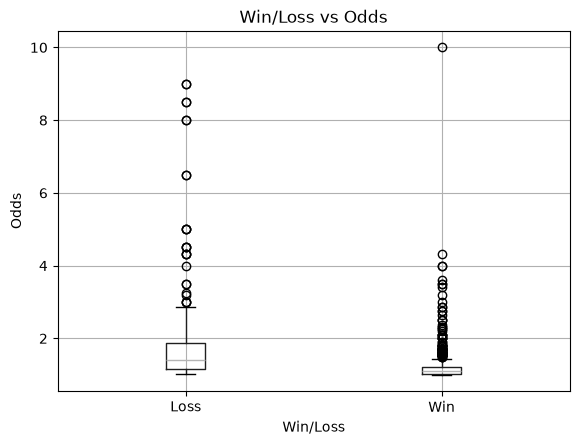

In [4]:
ax = df.boxplot(column=["dj_odds"], by="dj_win")

ax.figure.suptitle("")
ax.set_title("Win/Loss vs Odds")
ax.set_ylabel("Odds")
ax.set_xlabel("Win/Loss")
ax.set_xticklabels(["Loss", "Win"])

plt.show()

We can clearly see that there is some relationship between wins and odds. The interquartile range in the loss segment is larger, and there are clearly more losses from matches where Djokovic's odds were worse. The wins section is much more clustered together near the lower part of the odds range, however there is one outlier at odds of $10$ where Djokovic managed to win the match. Now, let us plot histograms for the distribution of the odds for both wins and losses. We use the odds-implied probabilities here, which need to be adjusted to account for the bookmaker margins that get included in the odds.

In [5]:
df_wins = df[df["dj_win"] == 1]
df_losses = df[df["dj_win"] == 0]

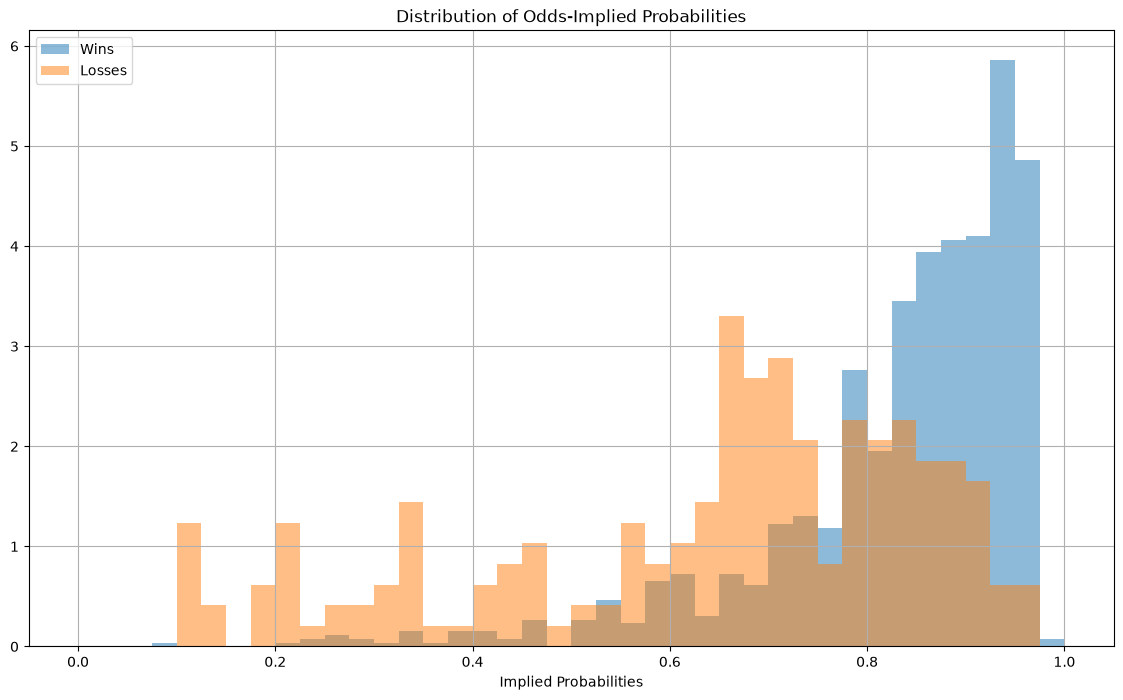

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

ax.hist((1 / df_wins["dj_odds"]) / (1/df_wins["dj_odds"] + 1/df_wins["opp_odds"]), 
        bins=np.linspace(0, 1, 41), density=True, alpha=0.5, label="Wins")
ax.hist((1 / df_losses["dj_odds"]) / (1/df_losses["dj_odds"] + 1/df_losses["opp_odds"]), 
        bins=np.linspace(0, 1, 41), density=True, alpha=0.5, label="Losses")

plt.legend()
plt.grid(True)
ax.set_title("Distribution of Odds-Implied Probabilities")
ax.set_xlabel("Implied Probabilities")
plt.show()


We can see that for the matches that Djokovic wins, his implied win probability is better/higher than those matches where he loses, since they are generally nearer to $1$ than for loss probabilities. This gives evidence for the fact that odds are a good indication of whether or not Djokovic wins or loses the match.

Now, we will evaluate the correctness of the bookmaker odds, by creating a decile plot illustrating the win rate for a bin of matches, vs the implied win probability for each bin given by the bookmaker odds. To form the bins, we will order all matches by Djokovic odds first, and then take $10$ equally-sized groups of consecutive matches.

In [7]:
df_sorted_by_odds = df.sort_values(by="dj_odds").reset_index(drop=True)[["dj_odds", "dj_win", "opp_odds"]]
values = {}

for block in np.array_split(df_sorted_by_odds, 10):

    probs = (1 / block[:, 0]) / ((1 / block[:, 0]) + (1 / block[:, 2]))
    avg_prob = np.mean(probs)
    true_rate = np.mean(block[:, 1], axis=0)

    values[avg_prob] = true_rate

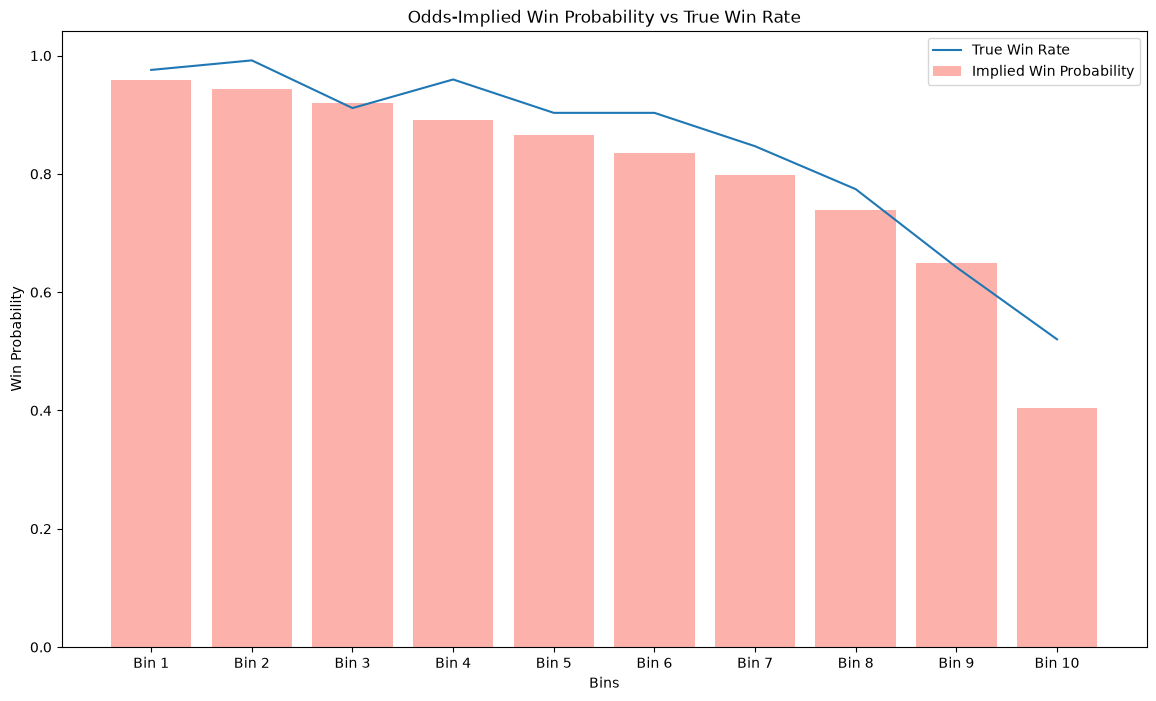

In [8]:
fig, ax = plt.subplots(figsize=(14, 8))
x = [f"Bin {i}" for i in np.arange(1, 11)]

ax.bar(x, height=values.keys(), alpha=0.6, color="salmon", label="Implied Win Probability")
ax.plot(x, values.values(), label="True Win Rate")

ax.set_xlabel("Bins")
ax.set_ylabel("Win Probability")
ax.set_title("Odds-Implied Win Probability vs True Win Rate")
plt.legend()
plt.show()

It seems that the market-implied win probabilities systematically underrate Djokovic's probability of winning. However, this may be a result of bookmakers choosing to load their margin onto the longshot (we have assumed the margin is evenly distributed across both players), and could also be a result of some survivorship bias. Djokovic went on to be very successful, it is common to have some underpricing of a player before their success is evident.

## 2. Age

Usually, athletes' performance is strongly correlated with age. Most athletes have a rise up towards their prime, usually somewhere between ages $25-30$. This relationship between age and the target variable can be represented by a quadratic age feature. Let us now examine Djokovic's win rate for each year he has been active.

In [9]:
age_data = df.groupby(np.floor(df["age_c"]).astype(int) + 28)["dj_win"].agg(["mean", "size"])
age_data["se"] = np.sqrt((age_data["mean"] * (1 - age_data["mean"])) / age_data["size"])

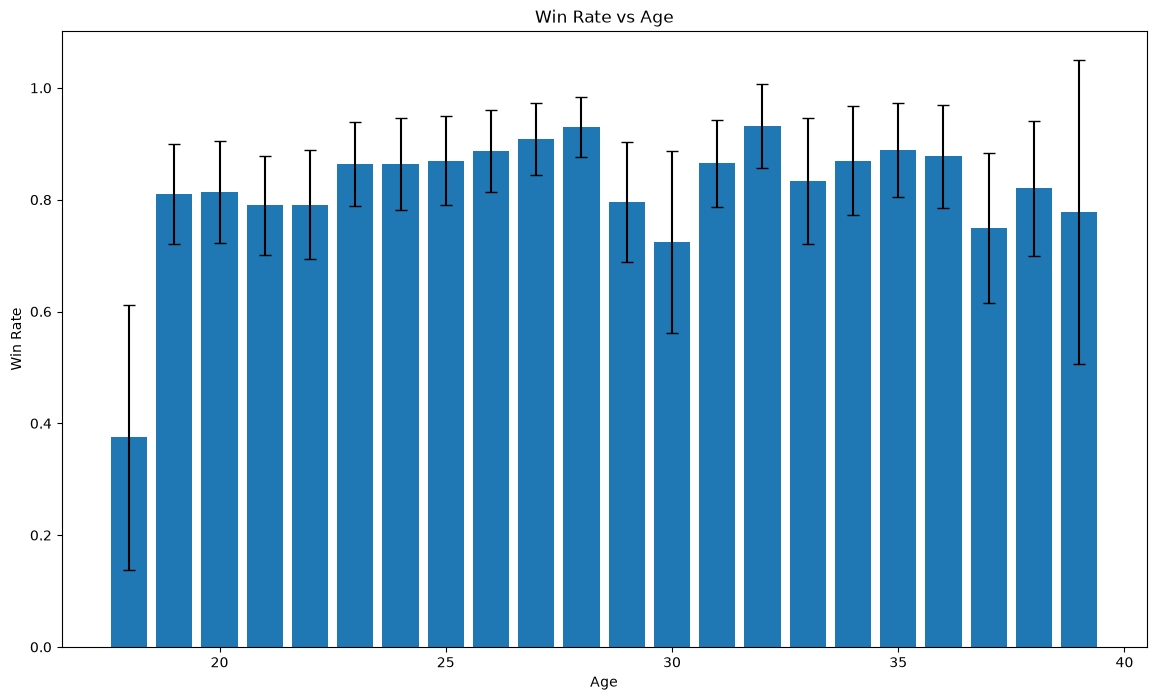

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8))
ax.bar(age_data.index, age_data["mean"], yerr=1.96 * age_data["se"], capsize=4)
ax.set_xlabel("Age")
ax.set_ylabel("Win Rate")
ax.set_title("Win Rate vs Age")
plt.show()

As we can see, although there is a rise to a peak between $25-30$, Djokovic's win rate still stays quite high until there is a slight drop off ages $37-39$. Our quadratic age variable is a simple approximation to this rise and fall.

## 3. Opponent Rank

Another good indication of who will win the match is also the opponent's rank. We will now observe the relationship between this and the match outcome.

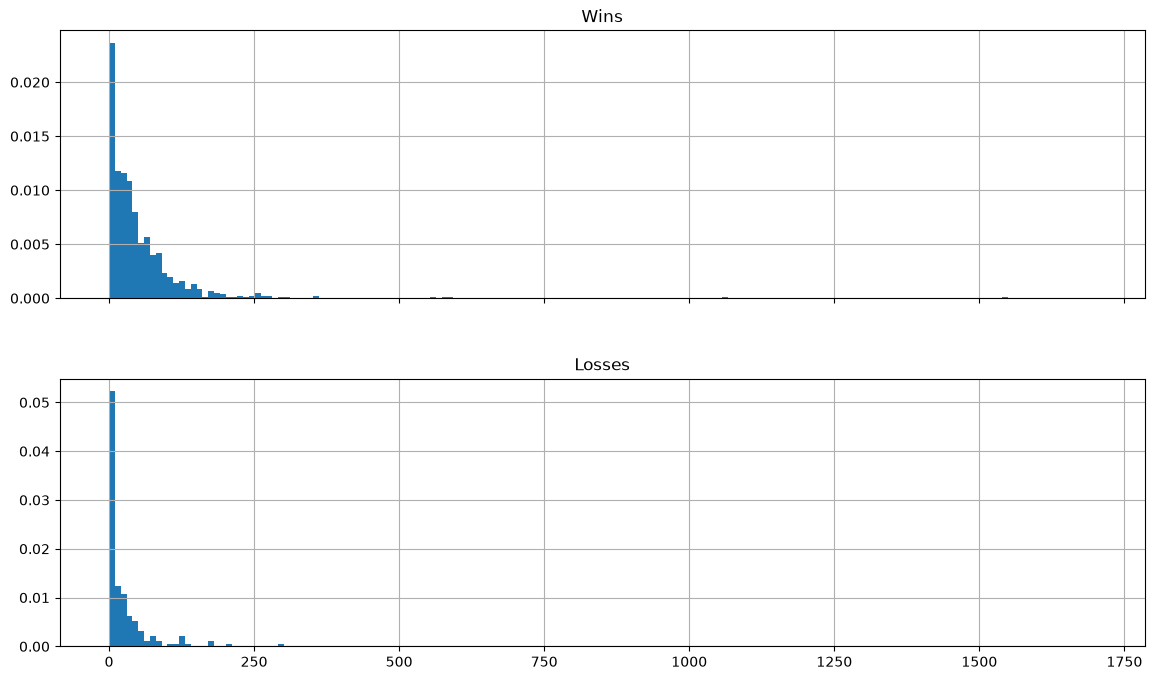

In [11]:
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

df_wins.hist(column="opp_rank", ax=ax[0], bins=np.linspace(0, 1700, 170), density=True)

df_losses.hist(column="opp_rank", ax=ax[1], bins=np.linspace(0, 1700, 170), density=True)

ax[0].set_title("Wins")
ax[1].set_title("Losses")

plt.show()

One can observe that, on average, the opponents that Djokovic loses to have better ranks than the players he wins against. This is intuitive.

## 4. Categorical Variables

We would now like to understand whether there is any relationship between the categorical variables Series, Surface, and Round against the win column.

In [12]:
def cat_summary(df, col, target="dj_win"):
    g = df.groupby(col)[target].agg(n="size", wins="sum", rate="mean")
    g["lift"] = g["rate"] - df[target].mean()
    g["se"] = np.sqrt(g["rate"] * (1 - g["rate"]) / g["n"])

    return g.sort_values("n", ascending=False)

In [13]:
series_order = [
    "ATP250", "ATP500", "Masters Cup", "Masters 1000", "Grand Slam"
    ]

g_series = cat_summary(df, "Series").reindex(series_order)
g_surface = cat_summary(df, "Surface")

round_order = [
    "1st Round", "2nd Round", "3rd Round", "4th Round",
    "Round Robin", "Quarterfinals", "Semifinals", "The Final",
]
g_round = cat_summary(df, "Round").reindex(round_order).dropna(subset=["n"])


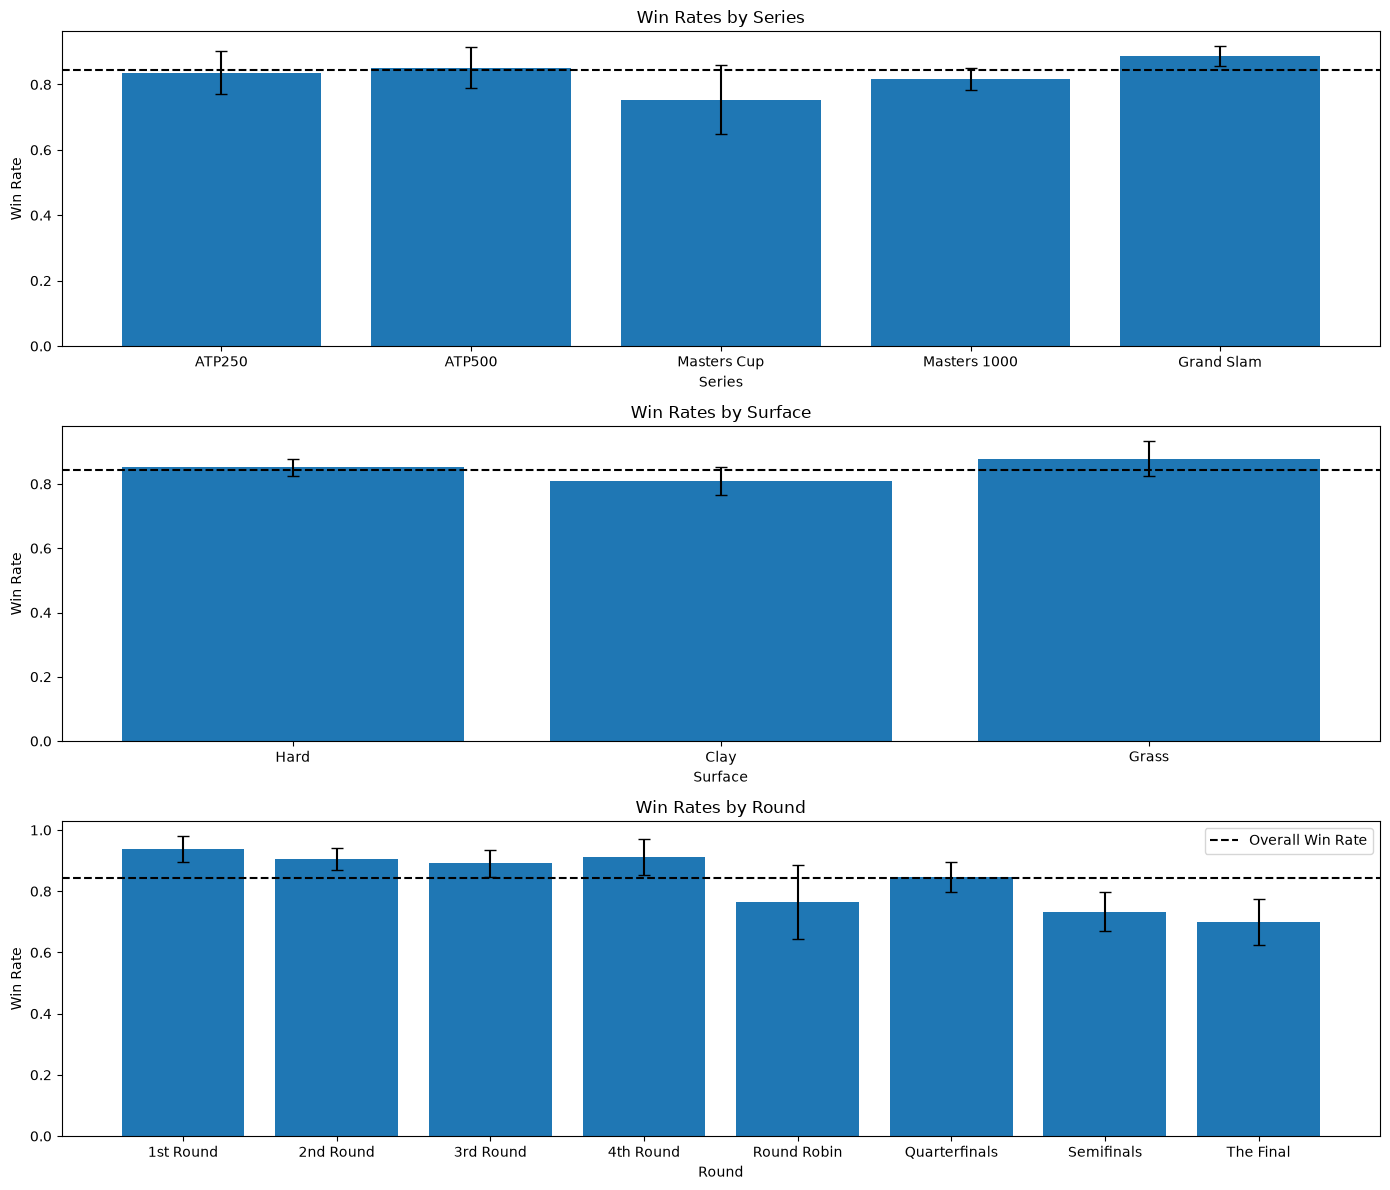

In [14]:
fig, ax = plt.subplots(3, 1, figsize=(14, 12))
ax[0].bar(g_series.index, g_series["rate"], yerr=1.96 * g_series["se"], capsize=4)
ax[0].axhline(df["dj_win"].mean(), ls="--", color="k", label="Overall Win Rate")
ax[0].set_title("Win Rates by Series")
ax[0].set_xlabel("Series")
ax[0].set_ylabel("Win Rate")

ax[1].bar(g_surface.index, g_surface["rate"], yerr=1.96 * g_surface["se"], capsize=4)
ax[1].axhline(df["dj_win"].mean(), ls="--", color="k", label="Overall Win Rate")
ax[1].set_title("Win Rates by Surface")
ax[1].set_xlabel("Surface")
ax[1].set_ylabel("Win Rate")

ax[2].bar(g_round.index, g_round["rate"], yerr=1.96 * g_round["se"], capsize=4)
ax[2].axhline(df["dj_win"].mean(), ls="--", color="k", label="Overall Win Rate")
ax[2].set_title("Win Rates by Round")
ax[2].set_xlabel("Round")
ax[2].set_ylabel("Win Rate")
plt.legend()
plt.tight_layout()
plt.show()

There are a couple of things to observe from this. Firstly, let's examine the Series findings. We can see that Djokovic performs the worst at Masters Cup, by a relatively noticeable margin, however the error bar is large indicating that the confidence interval is broad due to the fact that he hasn't played many Masters Cups. He also performs better in Grand Slams than in most other tournaments, with a small confidence interval indicating a large amount of evidence (many datapoints decreasing the standard error), due to him playing many Grand Slams.

For the Surface feature, he has similar win rates on Hard, Clay and Grass surfaces. No significant differences here.

For the Rounds findings, we can see that the win rate becomes lower as the tournament round becomes deeper. However, this is most probably due to the fact that Djokovic plays against better opponents as he progresses in the tournamant, not purely due to the specific round itself.

## 5. Numeric Variable Correlations

Let us now examine the collinearity of numeric columns. We expect that column pairs such as opponent odds and opponent rank will have some shared explanatory power.

In [15]:
df_numeric = df[["dj_pts", "dj_rank", "dj_odds", "opp_pts", "opp_rank", "opp_odds", "age_c"]]

<Axes: >

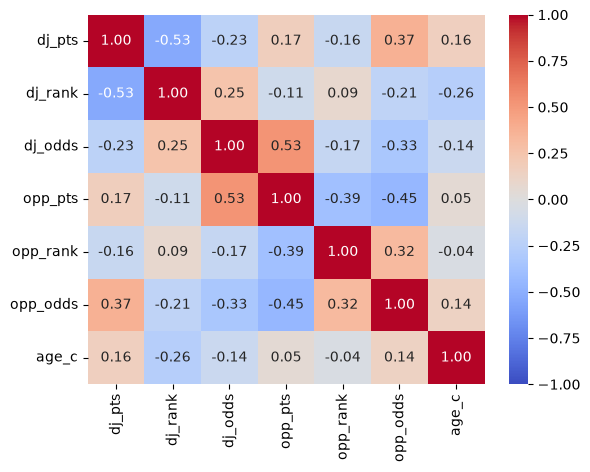

In [16]:
sns.heatmap(df_numeric.corr(), annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1)

Clearly, some collinearity exists between some of the variables, for example Djokovic's odds and the opponent's points have a correlation of $0.52$, and opponent's odds and points have a correlation of $-0.34$.

## 6. Residual View

The main goal of this project is to test whether our chosen features can add any further explanatory power for our target of Djokovic win/loss, than the odds already encode. In order to understand how much the odds miss, we will do some residual evaluation to understand how well the odds already track the win probability for each category. For each category in each categorical variable, we will calculate the margin-adjusted odds-implied win probability, and find the average value of dj_win - implied_probability for each category to understand how well the odds-implied probabilities track the true win rate. The further from zero (closer to $1 / -1$), the worse the bookmaker odds do.

In [17]:
def categorical_residual_view(variable):
    df_cat = df.groupby(variable)["dj_win"].agg(
        n="size", rate="mean"
        )
    
    implied_rates_cat = []
    ses = []
    for category in df_cat.index:
        df_category = df[df[variable] == category]
        implied_rate = (1 / df_category["dj_odds"]) / ((1 / df_category["dj_odds"]) + (1 / df_category["opp_odds"]))
        implied_rates_cat.append(np.mean(implied_rate))

        resid = df_category["dj_win"] - implied_rate
        ses.append(resid.sem())

    df_cat["odds_implied"] = implied_rates_cat

    df_cat["avg_resid"] = df_cat["rate"] - df_cat["odds_implied"]

    df_cat["se"] = ses

    return df_cat

In [18]:
df_series = categorical_residual_view("Series")
df_surface = categorical_residual_view("Surface")
df_round = categorical_residual_view("Round")

In [19]:
df["p_implied"] = (1/df["dj_odds"]) / (1/df["dj_odds"] + 1/df["opp_odds"])
df["resid"] = df["dj_win"] - df["p_implied"]
overall = df["resid"].mean()
print(f"The overall average residual is {overall}")

The overall average residual is 0.04255314761047699


We can see that, on average, the bookmaker odds underprice Djokovic by about $4\%$, since the market-implied win rate is $\approx 0.04$ less than the true win rate.

In [20]:
df_series

,n,rate,odds_implied,avg_resid,se
Series,,,,,
ATP250,122,0.836066,0.819741,0.016325,0.032644
ATP500,128,0.851562,0.818090,0.033473,0.028378
Grand Slam,423,0.886525,0.818550,0.067975,0.013334
Masters 1000,500,0.818000,0.786460,0.031540,0.016090
Masters Cup,65,0.753846,0.724903,0.028943,0.048437


In [21]:
df_surface

,n,rate,odds_implied,avg_resid,se
Surface,,,,,
Clay,325,0.809231,0.784786,0.024444,0.019162
Grass,140,0.878571,0.823487,0.055084,0.023955
Hard,773,0.851229,0.803332,0.047897,0.011961


In [22]:
df_round

,n,rate,odds_implied,avg_resid,se
Round,,,,,
1st Round,128,0.937500,0.871613,0.065887,0.018028
2nd Round,263,0.904943,0.877900,0.027043,0.017322
3rd Round,183,0.890710,0.861467,0.029244,0.022001
4th Round,91,0.912088,0.841686,0.070401,0.025550
Quarterfinals,202,0.846535,0.797477,0.049058,0.024632
Round Robin,47,0.765957,0.745968,0.019989,0.054544
Semifinals,184,0.733696,0.700609,0.033087,0.030507
The Final,140,0.700000,0.639717,0.060283,0.035979


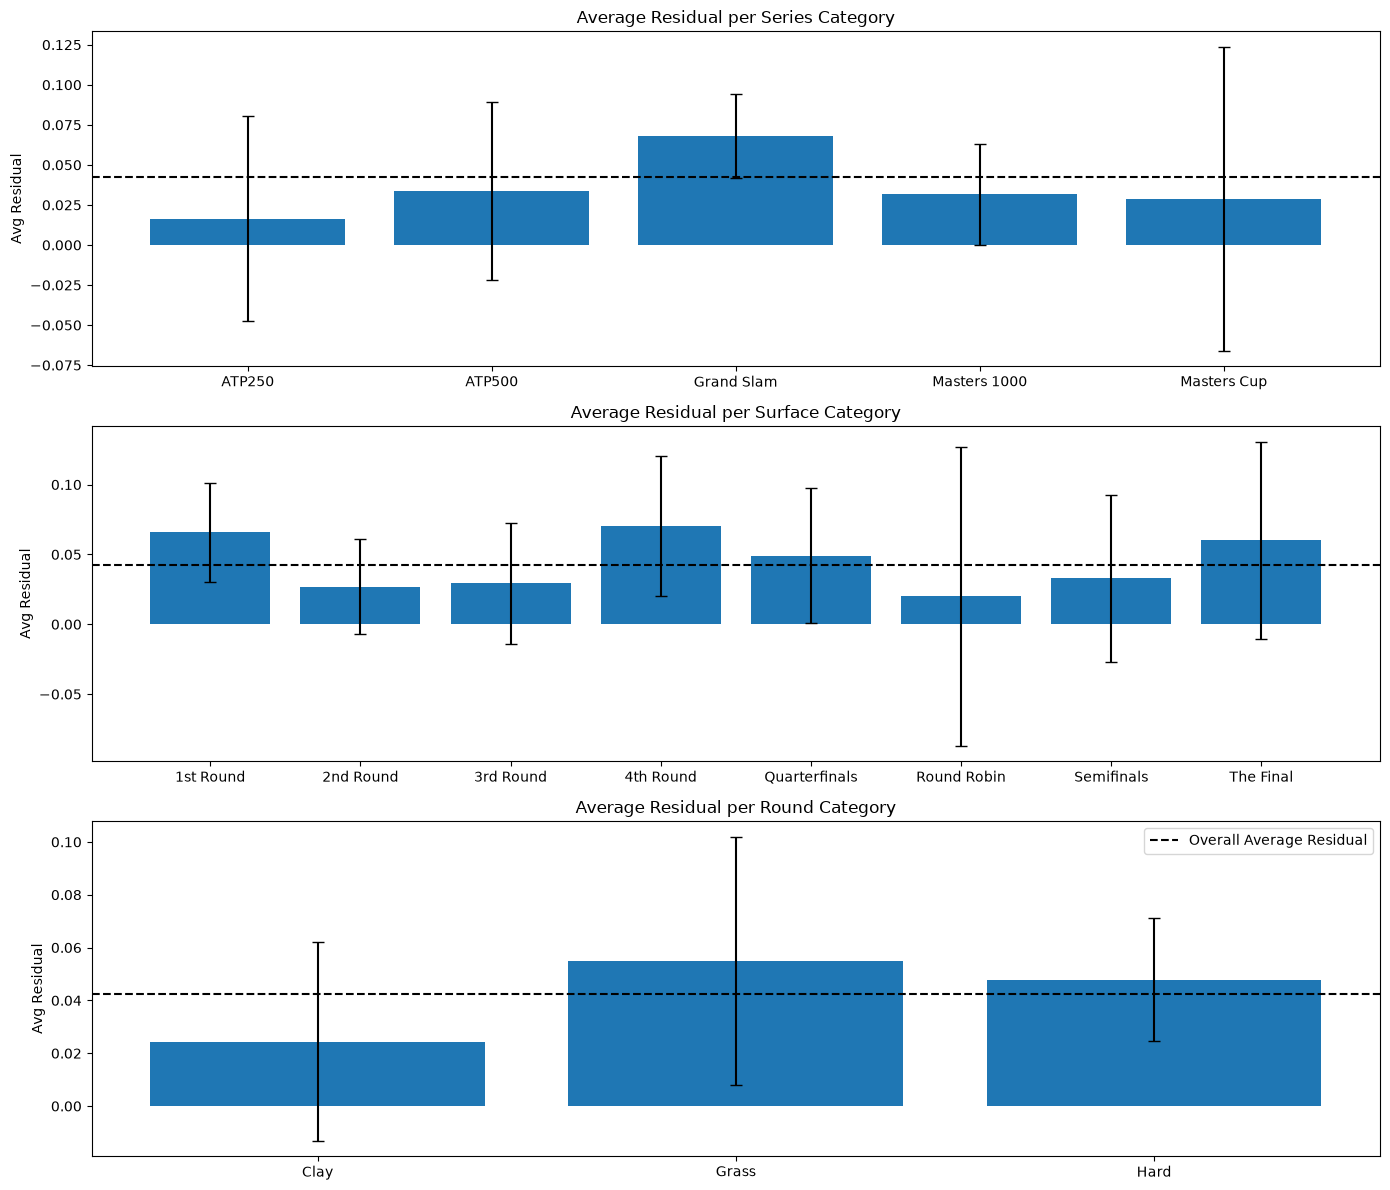

In [23]:
fig, ax = plt.subplots(3, 1, figsize=(14, 12))

ax[0].bar(df_series.index, height=df_series["avg_resid"], yerr=1.96*df_series["se"], capsize=4)
ax[0].axhline(overall, color="black", linestyle="--", label="Overall Average Residual")
ax[0].set_ylabel("Avg Residual")
ax[0].set_title("Average Residual per Series Category")

ax[1].bar(df_round.index, height=df_round["avg_resid"], yerr=1.96*df_round["se"], capsize=4)
ax[1].axhline(overall, color="black", linestyle="--", label="Overall Average Residual")
ax[1].set_ylabel("Avg Residual")
ax[1].set_title("Average Residual per Surface Category")

ax[2].bar(df_surface.index, height=df_surface["avg_resid"], yerr=1.96*df_surface["se"], capsize=4)
ax[2].axhline(overall, color="black", linestyle="--", label="Overall Average Residual")
ax[2].set_ylabel("Avg Residual")
ax[2].set_title("Average Residual per Round Category")

plt.tight_layout()
plt.legend()

plt.show()

The above indicates that, in each individual category, the bookmaker odds also underprice Djokovic. This can be seen from the fact that all residuals are above zero, showing that the true win probability/rate is systematically larger than the rate the odds imply. Almost all error bars overlap the overall average residual, indicating that there is no category-specific further underpricing occuring. The only category where this may be occuring is for Grand Slam series, where the average residual is $\approx 0.068$. This could indicate some additional underpricing in Grand Slams, however the error bar does also reach the overall average residual, so this is unlikely.

## 7. Base Rate BCE

Djokovic wins roughly $84\%$. Classification models can perform relatively well (in terms of accuracy) just by guessing win for every match. Using the accuracy as our performance metric cannot distinguish a model just predicting a win every time from a model genuinely trying to distinguish the match outcome using the features provided. Using the binary cross entropy instead means that our model's performance is not only dependendent on the side of $0.5$ that each predicted probability lands on, but rather on the accuracy and confidence of the model. This means that the probabilities themselves are what drives model performance; if a tuned model moves some of the probabilities in the correct direction, but not enough to change the accuracy, the BCE will still reflect that this model is making changes in the right direction. 

A good reference BCE is the BCE of the model trained with no features. In this case, the model just predicts the mean win rate probability. If the BCE of our model is lower than this baseline BCE, we know that the model is actually using the features in a way that actually moves predicted proababilities towards the true labels.

We need to first establish the win rate from the same training set that will be used in oncoming modelling, since this is the set a baseline-guessing model would have established the mean rate from. We can then use this mean rate prediction to find the train and test BCE, and since these will have been calculated from the exact same datasets as the oncoming models, they are directly comparable.

In [24]:
df_train, df_test = chrono_split_df(df, threshold=0.8)

win_rate = np.mean(df_train["dj_win"])
print(f"The baseline win rate is {win_rate:.2f}")

acc = df_test["dj_win"].mean()
print(f"The baseline accuracy on the test set is {acc:.3f}")

The baseline win rate is 0.84
The baseline accuracy on the test set is 0.839


Now we understand the probability a baseline-guessing model that has no available features (or no useful ones) would predict for every match. Now we can find the training and test BCE.

In [25]:
probs_train = np.full(df_train.shape[0], win_rate)
true_train = np.array(df_train["dj_win"].astype(int))

probs_test = np.full(df_test.shape[0], win_rate)


bce_train = -np.mean(true_train * np.log(probs_train) + (1 - true_train) * np.log(1 - probs_train))
bce_test = -np.mean(np.array(df_test["dj_win"].astype(int)) * np.log(probs_test) + (1 - np.array(df_test["dj_win"].astype(int))) * np.log(1 - probs_test))

print(f"The baseline train binary cross entropy is: {bce_train:.4f}")
print(f"The baseline test binary cross entropy is: {bce_test:.4f}")

The baseline train binary cross entropy is: 0.4322
The baseline test binary cross entropy is: 0.4419


Thus, if a classification model has a train BCE lower than $\approx 0.43$, and test BCE lower than $\approx 0.44$, then it is not just choosing the base rate and is actively changing its probability predictions in the correct direction, based on the provided features. We can also find out what the accuracy of win-guessing model will be.

In [26]:
print(f"Baseline accuracy (train): {df_train['dj_win'].mean() * 100:.2f}%")
print(f"Baseline accuracy (test):  {df_test['dj_win'].mean() * 100:.2f}%")

Baseline accuracy (train): 84.44%
Baseline accuracy (test):  83.87%


Note: we have simulated the behaviour of two different models here. The baseline BCEs come from a model that is predicting the training win rate for all matches in the test set. The baseline accuracy come from the test set accuracy of a model predicting a win every time. The accuracies of the two models would be the same since Djokovic's win rate is greater than $0.5$, however the BCEs would differ due to the difference in stated confidence.